In [47]:
import numpy as np
import matplotlib.pyplot as plt  
from sklearn.preprocessing import MinMaxScaler, StandardScaler

c:\Users\fpaul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.sparse import csr_matrix, issparse


# Questão 1

### Letra A

In [10]:
dataset = np.loadtxt("artificial1d.csv", delimiter=",", skiprows=1)

In [11]:
x = dataset[:, [0]]

y = dataset[:, [1]]

In [12]:
def plot(x, y, rmse, w):

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = w[0] + w[1] * x_line

    plt.scatter(x, y)       
    plt.plot(x_line, y_line)    

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Regressão Linear (RMSE={rmse:.4f})")

    plt.show()

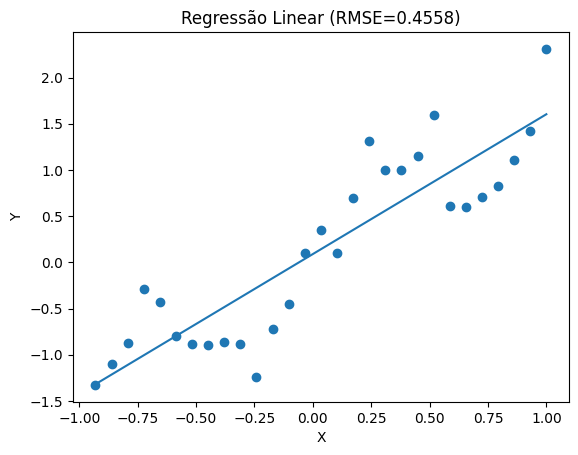

In [13]:
def regressao_linear(X_input, y):
    X = np.hstack((
        np.ones((X_input.shape[0], 1)),
        X_input
    ))

    w = np.linalg.inv(X.T @ X) @ X.T @ y

    y_hat = X @ w

    rmse = np.sqrt(np.mean((y - y_hat)**2))

    return w, rmse

w, rmse = regressao_linear(x, y)

plot(x, y, rmse, w)

### Letra B

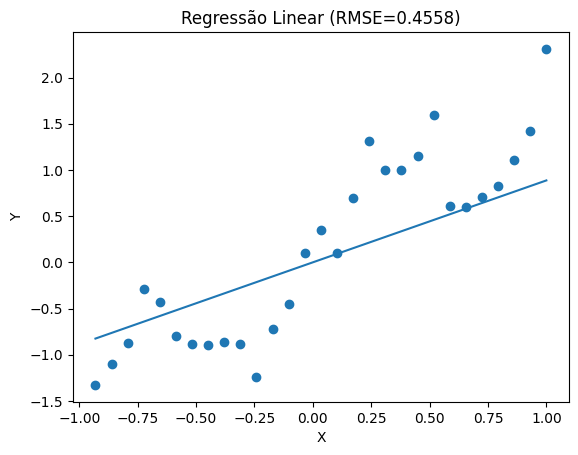

In [14]:
# Escreva o código aqui
def regressao_linear_gd(x, y, alpha, iteracoes):

    x_media = x.mean(axis=0, keepdims=True)
    x_std = x.std(axis=0)
    x_norm = (x - x_media) / x_std

    y_media = y.mean()
    y_std = y.std()
    y_norm = (y - y_media) / y_std

    X = np.hstack((np.ones((x_norm.shape[0], 1)), x_norm))

    N = X.shape[0]

    w = np.zeros((X.shape[1], 1))

    for _ in range(iteracoes):

        y_hat = X @ w
        erro = y_norm - y_hat

        gradiente = (X.T @ erro) / N

        w = w + alpha * gradiente

    y_pred_norm = X @ w

    y_pred = y_pred_norm * y_std + y_media

    rmse = np.sqrt(np.mean((y - y_pred) ** 2))

    return w, rmse
w, rmse = regressao_linear_gd(x=x, y=y, alpha=0.01, iteracoes=1000)
plot(x=x, y=y, rmse=rmse, w=w)

### Letra C

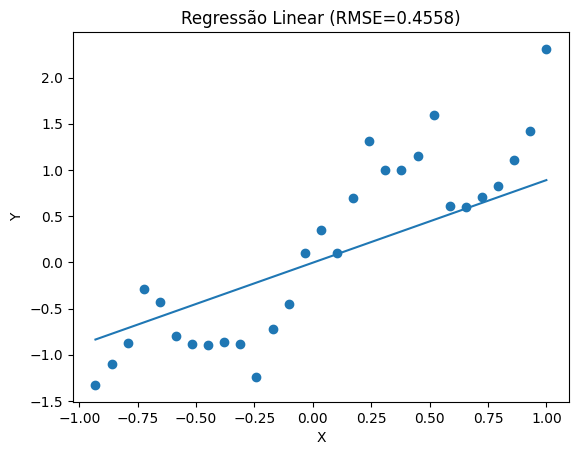

In [15]:
# Escreva o código aqui
def regressao_linear_sgd(x, y, alpha, epocas):

    x_media = x.mean(axis=0)
    x_std = x.std(axis=0)
    x_norm = (x - x_media) / x_std

    y_media = y.mean()
    y_std = y.std()
    y_norm = (y - y_media) / y_std

    X = np.hstack((np.ones((x_norm.shape[0], 1)), x_norm))

    N = X.shape[0]

    w = np.zeros((X.shape[1], 1))

    for _ in range(epocas):
        for i in range(N):

            xi = X[i].reshape(-1,1)
            yi = y_norm[i]

            y_hat = w.T @ xi
            erro = yi - y_hat

            w = w + alpha * erro * xi

    y_pred_norm = X @ w

    y_pred = y_pred_norm * y_std + y_media

    rmse = np.sqrt(np.mean((y - y_pred) ** 2))

    return w, rmse

w, rmse = regressao_linear_sgd(x=x, y=y, alpha=0.01, epocas=100)
plot(x=x, y=y, rmse=rmse, w=w)

# Questão 2

In [33]:
california = np.loadtxt("california.csv", delimiter=",", skiprows=1)
X = california[:, :8] 
y = california[:, 8]  

### Letra A

In [34]:
def separa_dados(X, y, treino=0.8):
    n = X.shape[0]

    indices = np.random.permutation(n)

    split = int(n * treino)

    train_idx = indices[:split]
    test_idx = indices[split:]

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test

In [35]:
X_train, X_test, y_train, y_test = separa_dados(X, y, treino=0.8)

### Letra B

In [36]:
def regressao_polinomial(x, y, grau):

    X = np.ones((x.shape[0], 1))

    for i in range(1, grau + 1):
        X = np.hstack((X, x**i))

    w = np.linalg.inv(X.T @ X) @ X.T @ y

    y_hat = X @ w

    rmse = np.sqrt(np.mean((y - y_hat)**2))

    return w, rmse

In [37]:
graus = []
rmse_treino = []
rmse_teste = []

for grau in range(1, 14):
    w, rmse_train = regressao_polinomial(X_train, y_train, grau)

    X_test_poly = np.ones((X_test.shape[0], 1))
    for i in range(1, grau + 1):
        X_test_poly = np.hstack((X_test_poly, X_test**i))

    y_pred_test = X_test_poly @ w
    rmse_test = np.sqrt(np.mean((y_test - y_pred_test)**2))

    graus.append(grau)
    rmse_treino.append(rmse_train)
    rmse_teste.append(rmse_test)

    print(f"Grau {grau} -> RMSE treino: {rmse_train:.4f} | RMSE teste: {rmse_test:.4f}")

Grau 1 -> RMSE treino: 0.6750 | RMSE teste: 0.6533
Grau 2 -> RMSE treino: 0.6496 | RMSE teste: 0.6462
Grau 3 -> RMSE treino: 0.6232 | RMSE teste: 0.6408
Grau 4 -> RMSE treino: 0.8134 | RMSE teste: 0.8441
Grau 5 -> RMSE treino: 4.4526 | RMSE teste: 4.4774
Grau 6 -> RMSE treino: 3.6708 | RMSE teste: 2.7347
Grau 7 -> RMSE treino: 1.2590 | RMSE teste: 1.1544
Grau 8 -> RMSE treino: 7.5555 | RMSE teste: 6.6790
Grau 9 -> RMSE treino: 4.7483 | RMSE teste: 8.3435
Grau 10 -> RMSE treino: 54.8059 | RMSE teste: 186.6677
Grau 11 -> RMSE treino: 95.5422 | RMSE teste: 27077.2041
Grau 12 -> RMSE treino: 238.1092 | RMSE teste: 31044.6722
Grau 13 -> RMSE treino: 559979.5104 | RMSE teste: 425999141.7115


### Letra C

In [38]:
def plot_2(graus, titulo, rmse):
    plt.figure()
    plt.plot(graus, rmse, marker='o')
    plt.title(titulo)
    plt.xlabel("Grau do Polinômio")
    plt.ylabel("RMSE")
    plt.grid()
    plt.show()

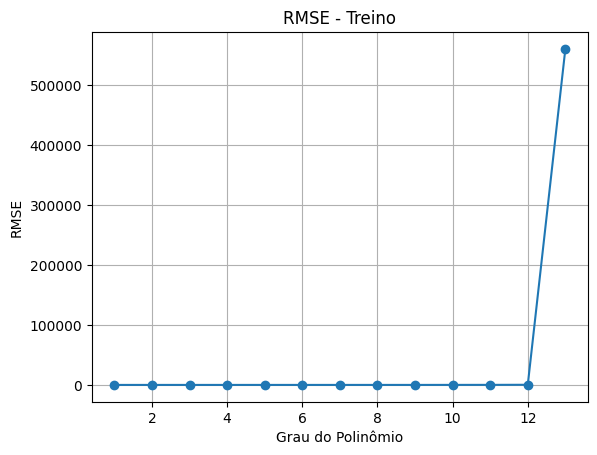

In [42]:
plot_2(graus=graus, titulo="RMSE - Treino", rmse=rmse_treino)

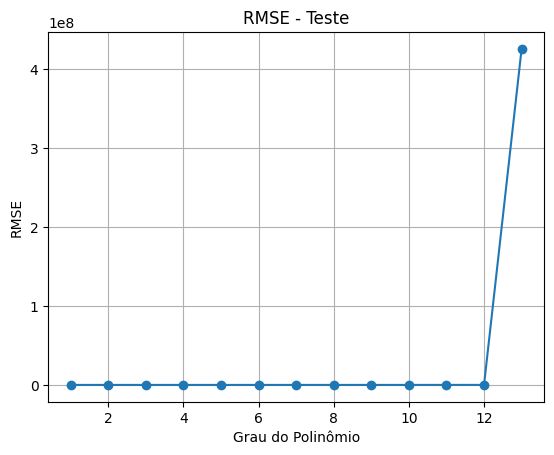

In [40]:
plot_2(graus=graus, titulo="RMSE - Teste", rmse=rmse_teste)

### Letra D

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train_norm = scaler_X.fit_transform(X_train)
X_test_norm = scaler_X.transform(X_test)

y_train_norm = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_norm = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [43]:
def cria_matriz_polinomial(X, grau):
    X_poly = np.ones((X.shape[0], 1))
    
    for i in range(1, grau + 1):
        X_poly = np.hstack((X_poly, X**i))
    
    return X_poly

In [ ]:
def regressao_polinomial_l2(X, y, grau, lamb=0.01):
    X_poly = cria_matriz_polinomial(X, grau)

    n_features = X_poly.shape[1]
    I = np.eye(n_features)

    I[0, 0] = 0

    w = np.linalg.inv(X_poly.T @ X_poly + lamb * I) @ X_poly.T @ y

    y_hat = X_poly @ w
    rmse = np.sqrt(np.mean((y - y_hat)**2))

    return w, rmse

In [ ]:
graus = []
rmse_treino_l2 = []
rmse_teste_l2 = []

for grau in range(1, 14):
    w, rmse_train = regressao_polinomial_l2(X_train_norm, y_train_norm, grau, lamb=0.01)

    X_test_poly = cria_matriz_polinomial(X_test_norm, grau)
    y_pred_test_norm = X_test_poly @ w

    rmse_test = np.sqrt(np.mean((y_test - y_pred_test)**2))

    graus.append(grau)
    rmse_treino_l2.append(rmse_train)
    rmse_teste_l2.append(rmse_test)

    print(f"[L2] Grau {grau} -> RMSE treino: {rmse_train:.4f} | RMSE teste: {rmse_test:.4f}")

[L2] Grau 1 -> RMSE treino: 0.6750 | RMSE teste: 0.6533
[L2] Grau 2 -> RMSE treino: 0.6496 | RMSE teste: 0.6455
[L2] Grau 3 -> RMSE treino: 0.6242 | RMSE teste: 0.6434
[L2] Grau 4 -> RMSE treino: 0.6181 | RMSE teste: 0.6481
[L2] Grau 5 -> RMSE treino: 0.6150 | RMSE teste: 0.6379
[L2] Grau 6 -> RMSE treino: 2.8235 | RMSE teste: 2.2035
[L2] Grau 7 -> RMSE treino: 0.7813 | RMSE teste: 1.0381
[L2] Grau 8 -> RMSE treino: 5.8717 | RMSE teste: 6.2986
[L2] Grau 9 -> RMSE treino: 17.0385 | RMSE teste: 17.3928
[L2] Grau 10 -> RMSE treino: 110.0381 | RMSE teste: 109.6867
[L2] Grau 11 -> RMSE treino: 47.4891 | RMSE teste: 291.0055
[L2] Grau 12 -> RMSE treino: 248.5931 | RMSE teste: 255554.8369
[L2] Grau 13 -> RMSE treino: 11925.9852 | RMSE teste: 27998924.1963


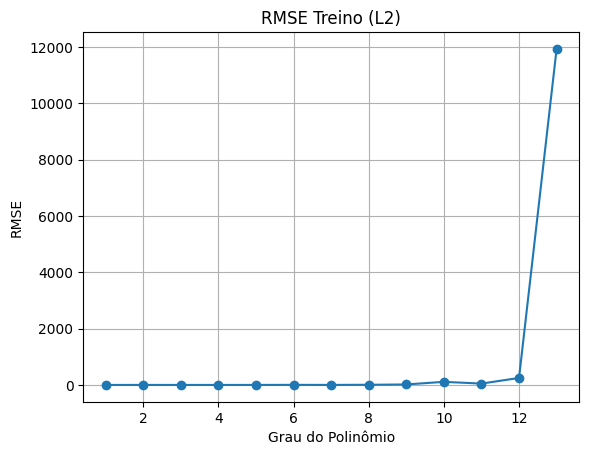

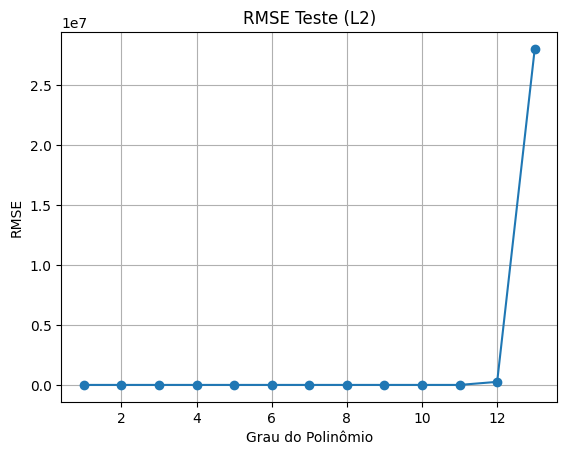

In [46]:
plot_2(graus, "RMSE Treino (L2)", rmse_treino_l2)
plot_2(graus, "RMSE Teste (L2)", rmse_teste_l2)